# Introduction

This notebook builds an end‑to‑end, visual story of how a pretrained GoogLeNet (InceptionV1) processes images and what its internal features “look like.”

## Model and input

- A pretrained GoogLeNet model is loaded and set to evaluation mode so it behaves like a fixed vision model rather than a trainable network.  
- An example RGB image is loaded, resized, normalized, and converted into a tensor of shape \([1, 3, H, W]\), where 1 is the batch size and 3 are the input color channels.

## Filters, channels, and feature maps

- In the first convolutional layer, the weights have shape \([64, 3, 7, 7]\).  
  - Each \([3, 7, 7]\) block is a **filter**: a small set of learned weights that looks at a 7×7 patch across the 3 input channels.  
  - Each filter produces one **feature map** (or **output channel**) when slid over the input, so 64 filters give 64 feature maps.  
- Conceptually, each output channel corresponds to one learned **feature type** (like a particular edge orientation or color contrast), realized by many identical neurons tiled over the spatial grid.

## Capturing activations with hooks

- Forward hooks are attached to several layers: an early layer (`conv1`), a middle Inception block (`inception3a`), and a deep block (`inception5b`).  
- When an image is passed through the model, each hook saves that layer’s **activations**: tensors of shape \([1, C, H', W']\), where \(C\) is the number of channels (features) at that depth.  
- These activations are the outputs of the layers after their convolutions and nonlinearities, representing how strongly each feature fires at each spatial location.

## Visualizing feature maps

- For each hooked layer, the batch dimension is removed to get a tensor \([C, H', W']\).  
- A subset of channels is selected, and each channel’s feature map is normalized to \([0, 1]\) and plotted with a colormap (for example, `viridis`).  
- In these visualizations:
  - **Bright (high) values show where a feature is strongly active**, meaning the corresponding filter has found its preferred pattern in that region.  
  - **Dark (low) values show where it is not**, so the pattern is absent or weak there.  
- Comparing early, middle, and deep layers reveals a feature hierarchy:
  - Early maps emphasize simple edges and color contrasts.  
  - Middle maps highlight textures and object parts.  
  - Deep maps become sparse and abstract, lighting up around high‑level object regions.

In [61]:
# Import the necessary libraries for tensor operations, feature visualization and image transformation.
import torch
import torchvision.transforms.v2 as T
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import requests

# Set the device to GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

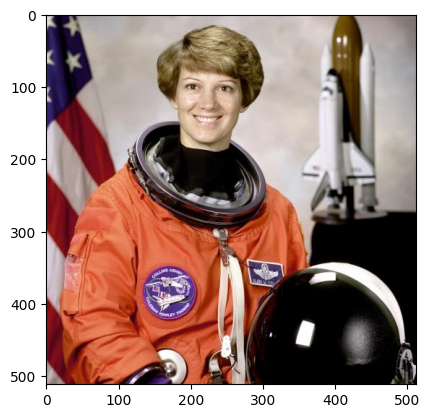

In [62]:
image_url = 'https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/astronaut.jpg'
response = requests.get(image_url, stream=True)
img = Image.open(response.raw).convert("RGB")

plt.imshow(img)
plt.axis()
plt.show()

In [63]:
# Load the pre-trained GoogLeNet model with the best available weights (currently alias for IMAGENET1K_V2) and move it to the specified device (GPU if available, else CPU).
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT).to(device)

# Set the model to evaluation mode. This disables dropout and batch normalization updates.
model.eval()

# Standard ImageNet preprocessing for torchvision GoogLeNet
# Get the default weights which also contain the preprocessing transforms.
weights = models.GoogLeNet_Weights.DEFAULT

# Retrieve the standard preprocessing transformations (e.g., resize, center crop, tensor conversion, normalization).
preprocess = weights.transforms()

# Apply the preprocessing transformations to the input image, add a new dimension of size 1 at axis 0 of the tensor (unsqueeze(0)), and move it to the specified device.
input_tensor = preprocess(img).unsqueeze(0).to(device)

# Display the preprocessed input tensor. Its shape will be [1, 3, H, W] (batch size, channels, height, width).
input_tensor.shape

torch.Size([1, 3, 224, 224])

First conv weight shape: torch.Size([64, 3, 7, 7])


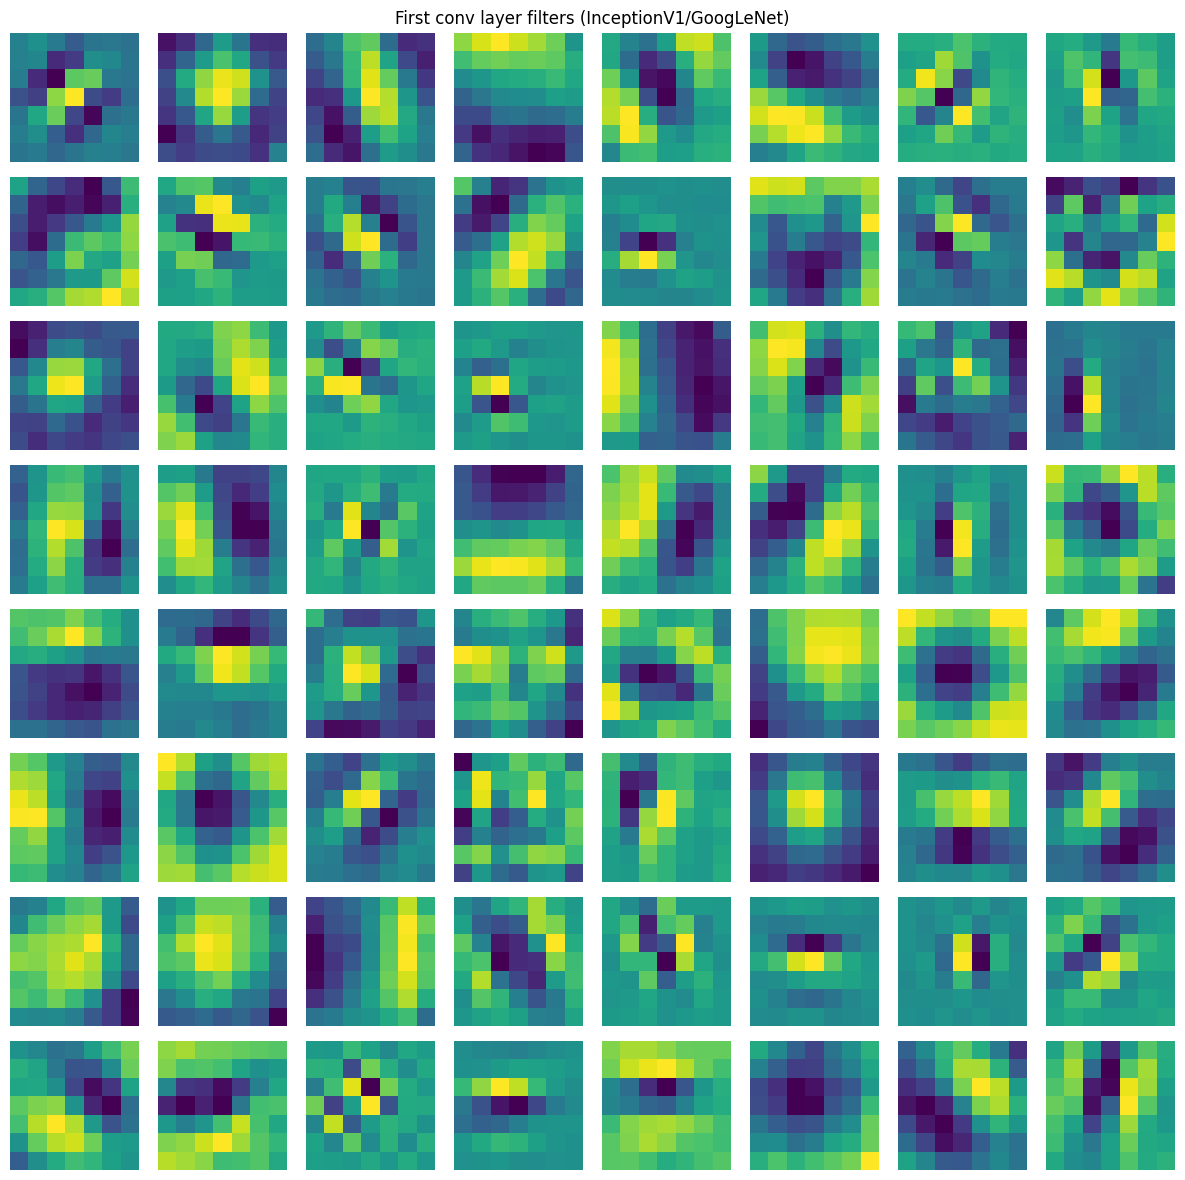

In [64]:
# Select the first convolutional layer of the model.
first_conv = model.conv1

# Get the learned filters (weights): [out_channels, in_channels, H, W]
filters = first_conv.conv.weight.data.clone().cpu()

print("First conv weight shape:", filters.shape)

# Visualize each filter (showing just the first input channel)
num_filters_to_show = min(64, filters.shape[0])

plt.figure(figsize=(12, 12))
for i in range(num_filters_to_show):
    plt.subplot(8, 8, i + 1)
    # Select the first channel (e.g., red) of the current filter for visualization.
    f = filters[i, 0, :, :]
    # Normalize the filter values to a 0-1 range for proper display.
    f = (f - f.min()) / (f.max() - f.min() + 1e-5)
    plt.imshow(f)
    plt.axis("off")

plt.suptitle("First conv layer filters (InceptionV1/GoogLeNet)")
plt.tight_layout()
plt.show()

In [65]:
# Dictionary to store activations
activations = {}

def get_activation(name):
    def hook(model, input, output):
        # detach and move to CPU so it is safe to use after the forward pass
        activations[name] = output.detach().cpu()
    return hook

# Register hook on the first, middle and deep layers
handles = []
handles.append(model.conv1.register_forward_hook(get_activation("early_conv1")))
handles.append(model.inception3a.register_forward_hook(get_activation("middle_inception3a")))
handles.append(model.inception5b.register_forward_hook(get_activation("deep_inception5b")))

In [66]:
with torch.no_grad():
    _ = model(input_tensor)  # full forward pass; hook will capture conv1 output

# Retrieve the activation
for name, act in activations.items():
    print(name, "activation shape:", act.shape)

early_conv1 activation shape: torch.Size([1, 64, 112, 112])
middle_inception3a activation shape: torch.Size([1, 256, 28, 28])
deep_inception5b activation shape: torch.Size([1, 1024, 7, 7])


In [67]:
def visualize_feature_maps(activation, title, num_maps=64):
    """
    activation: tensor of shape [1, C, H, W]
    num_maps: how many channels to visualize
    """
    act = activation.squeeze(0)  # [C, H, W]
    C = act.shape[0]
    num = min(num_maps, C)

    plt.figure(figsize=(12,12))
    for i in range(num):
        fmap = act[i]
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-5)

        plt.subplot(8, 8, i + 1)
        plt.imshow(fmap, cmap="viridis")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


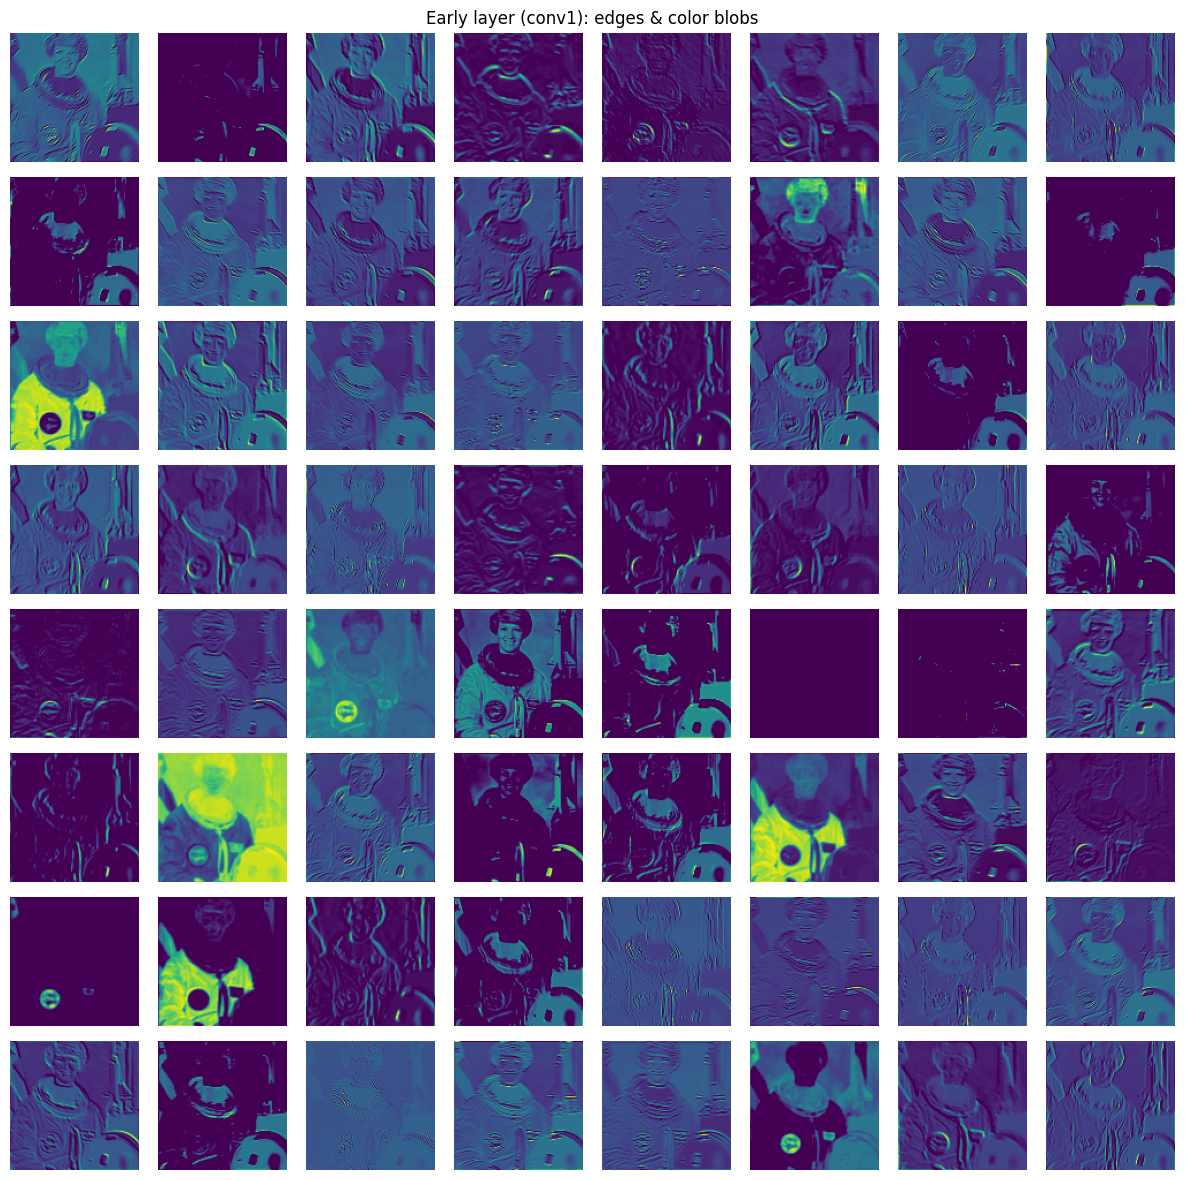

In [68]:
visualize_feature_maps(
    activations["early_conv1"],
    "Early layer (conv1): edges & color blobs",
    num_maps=64
)


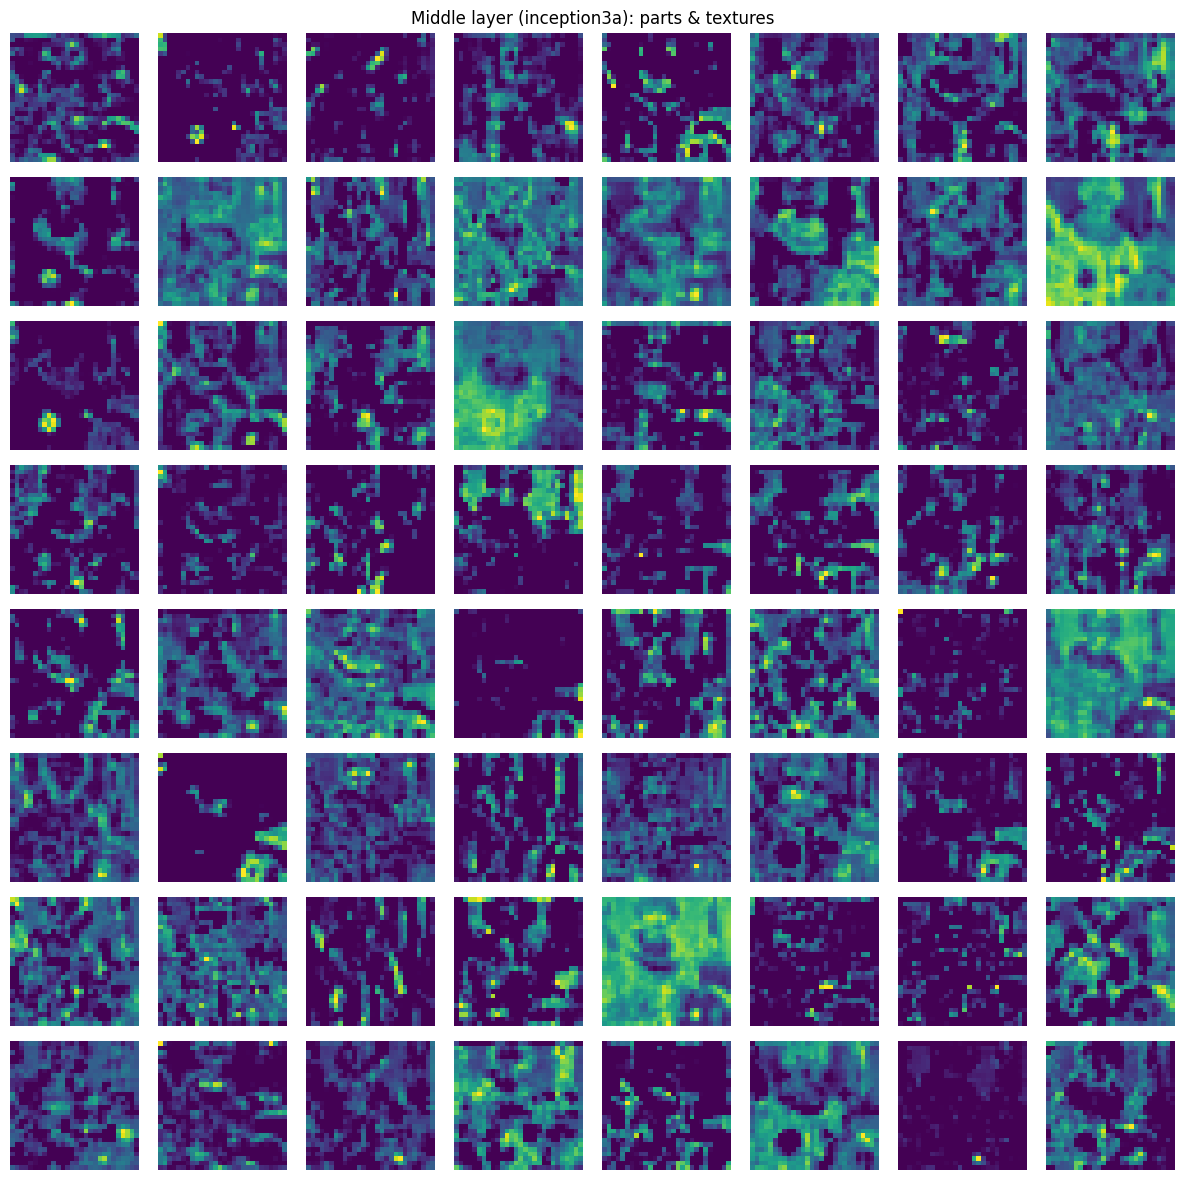

In [69]:
visualize_feature_maps(
    activations["middle_inception3a"],
    "Middle layer (inception3a): parts & textures",
    num_maps=64
)

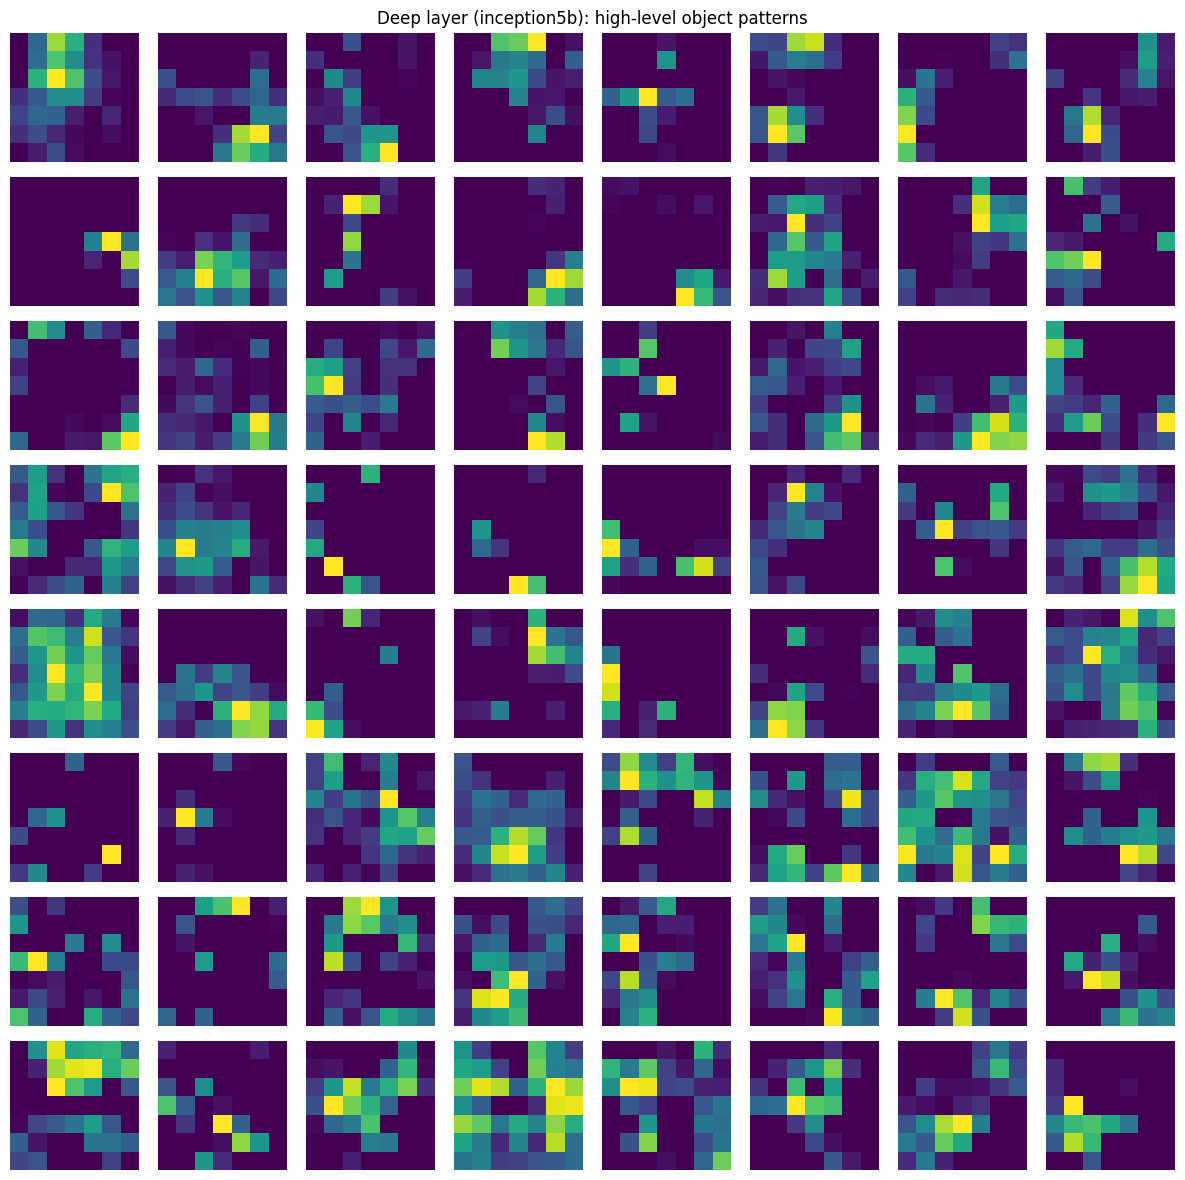

In [70]:
visualize_feature_maps(
    activations["deep_inception5b"],
    "Deep layer (inception5b): high-level object patterns",
    num_maps=64
)

## Activation maximization with torch‑lucent

- To see what a feature “likes” in the abstract, rather than on a specific photo, activation maximization is used on the `inception4b` (mixed4b‑like) layer.  
- For each of 10 channels in `inception4b`, a separate synthetic image is optimized so that the activation of that channel becomes large.  
  - The objective targets one channel at a time via `objectives.channel(target_layer, i, batch=0)`.  
  - The optimization iteratively updates the input image (not the model weights) to increase the chosen channel’s activation.  
- The image parameterization uses:
  - `fft=True`: the image is represented in the Fourier domain, encouraging smoother, less noisy patterns.  
  - `decorrelate=True`: color channels are decorrelated to resemble natural‑image statistics, making results more interpretable.

In your results for the first 10 channels of `inception4b`, the activation‑maximized images clearly show diverse **mid‑level textures and parts**:  
- Some channels prefer bubble‑like circles, tiled eye‑like squares, or swirl/spiral patterns.  
- Others prefer cauliflower‑like blobs, wavy bands, stacked ridges, spiky starbursts, cone‑like shapes, or dense curled‑hair textures with small line segments.  
This confirms that `inception4b` has specialized into a rich set of texture and part detectors, with each channel responding strongly to a particular family of shapes and colors.

## Conceptual picture tying it all together

- **Filters (weights)** define what each feature / channel is looking for.  
- **Feature maps (activations)** show where in a particular image those features are present.  
- **Hooks and feature‑map visualizations** show the hierarchy of representations for a given input image, from edges to shapes to object‑like patterns.  
- **Activation maximization with torch‑lucent** shows, for each chosen channel in `inception4b`, a synthetic “prototypical” pattern that most strongly excites that feature, revealing that this mid‑layer is composed of many distinct texture and part detectors.

In [71]:
!pip install torch-lucent

In [72]:
import torch
from torchvision import models
from lucent.optvis import render, param, objectives

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Pretrained GoogLeNet (InceptionV1)
weights = models.GoogLeNet_Weights.DEFAULT
model = models.googlenet(weights=weights).to(device)
model.eval()

Using device: cuda


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [73]:
# Fourier + color decorrelation parameterization (Lucent default for nice images)
def param_f():
    return param.image(w=224, h=224, fft=True, decorrelate=True)

In [74]:
# Define the target layer and number of channels to visualize
target_layer = "inception4b"
num_channels_to_visualize = 10  # Visualize the first 10 channels for example

# Prepare a list to store the generated images
list_of_images = []

# Generate an image for each channel individually
for i in range(num_channels_to_visualize):
    # Create an objective for a single channel
    objective = objectives.channel(target_layer, i, batch=0)

    # Render the visualization for this single channel
    images = render.render_vis(
        model,
        objective,
        param_f=param_f,
        show_image=False,
        thresholds=(512,)
    )

    # Add the generated image to our list (images is a list with one item per threshold)
    list_of_images.append(images[0][0]) # Assuming images[0] is the batch, and we take the first (and only) image from it

print(f"Generated {len(list_of_images)} images.")

100%|██████████| 512/512 [00:12<00:00, 42.48it/s]

Generated 10 images.


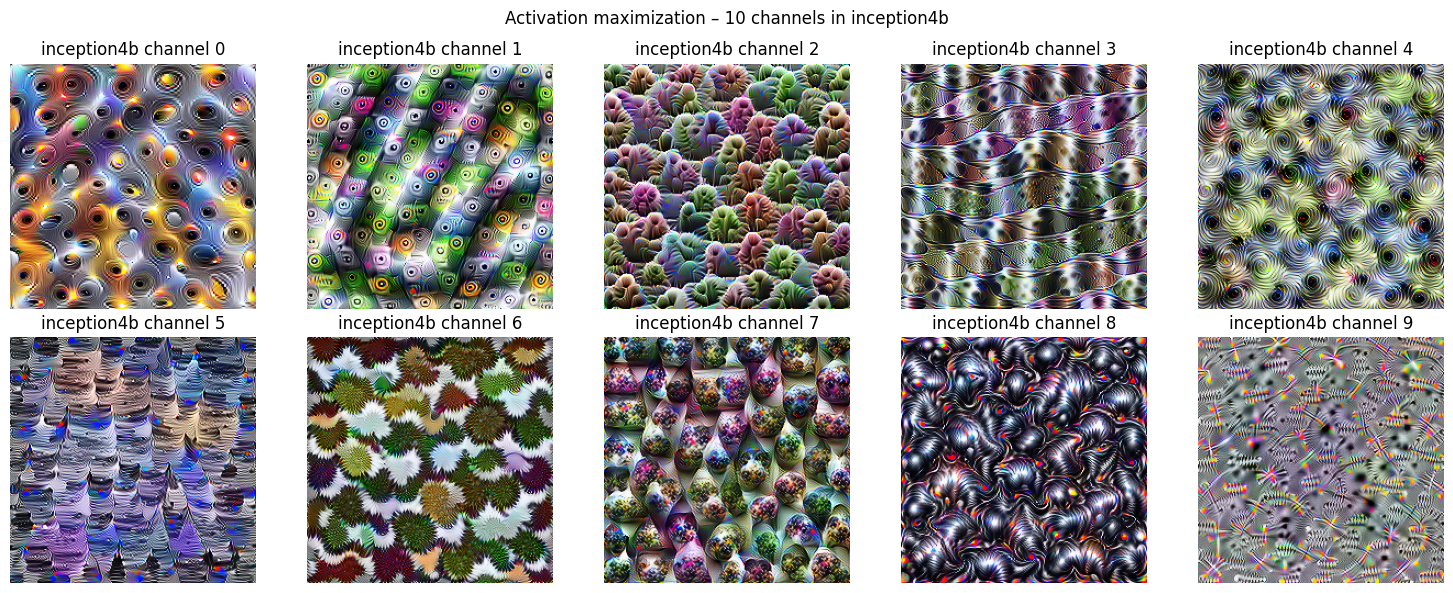

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, img in enumerate(list_of_images):
    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(f"{target_layer} channel {i}")
    ax.axis("off")

plt.suptitle(f"Activation maximization – 10 channels in {target_layer}")
plt.tight_layout()
plt.show()
